In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

In [21]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
llm =  model = ChatGoogleGenerativeAI(
    model="gemini-3.8-flash",
    temperature=0
)


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

ValidationError: 1 validation error for ChatGoogleGenerativeAI
model
  Field required [type=missing, input_value={'model_kwargs': {}, 'bas...SecretStr('**********')}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

In [ ]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

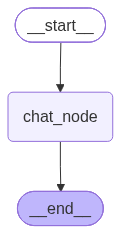

In [ ]:
chatbot

In [ ]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

GoogleAuthenticationError: Error calling model 'gemini-3.8-flash' (UNAUTHENTICATED): 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'ACCESS_TOKEN_TYPE_UNSUPPORTED', 'metadata': {'method': 'google.ai.generativelanguage.v1beta.GenerativeService.GenerateContent', 'service': 'generativelanguage.googleapis.com'}}]}}